In [1]:
import joblib
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
from sklearn.model_selection import train_test_split


df = pd.read_csv("../data/processed/model_data.csv")
X = df.drop("default", axis=1)
y = df["default"]

_, X_test, _, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

logistic_model = joblib.load("../models/logistic_regression.pkl")
random_forest_model = joblib.load("../models/random_forest.pkl")
xgb_model = joblib.load("../models/xgboost.pkl")

In [2]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_model
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.685899,0.385640,0.734838,0.505825,0.779853
1,Random Forest,0.849429,0.687606,0.571227,0.624037,0.843750
2,XGBoost,0.868713,0.798107,0.535261,0.640777,0.869535


In [3]:
best_model_name = results_df.loc[results_df['ROC AUC'].idxmax()]['Model']
best_model = models[best_model_name]

joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

['../models/best_model.pkl']

### 5.4 Confusion Matrix Analysis

The confusion matrix breaks down model predictions against actual loan outcomes across four critical quadrants:
- **True Negatives (TN)**: Good credit applicants correctly approved (business profit).
- **False Positives (FP)**: Creditworthy applicants mistakenly denied (Type I error / forgone revenue).
- **False Negatives (FN)**: Defaulters mistakenly approved (Type II error / direct capital loss).
- **True Positives (TP)**: Defaulters correctly intercepted and rejected (capital preservation).

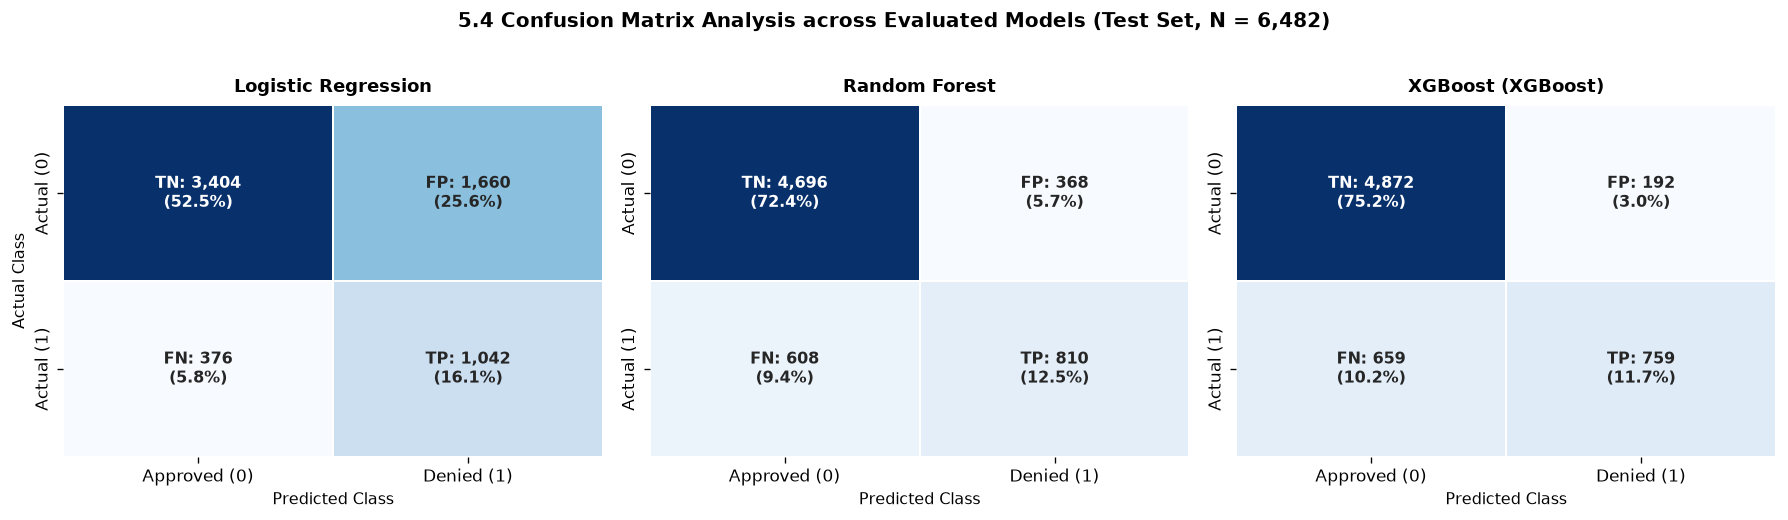

Champion Model (XGBoost) Diagnostic Summary:
  • True Negatives (TN): 4,872 (96.21% Specificity)
  • False Positives (FP): 192 (3.79% Type I Error)
  • False Negatives (FN): 659 (46.47% Type II Error)
  • True Positives (TP): 759 (53.53% Recall/Sensitivity)


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrices for all evaluated models
models_cm = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    f"XGBoost ({best_model_name})": best_model
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), dpi=120)

for ax, (name, m) in zip(axes, models_cm.items()):
    y_pred = m.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype('float') / cm.sum() * 100
    labels = [
        [f'TN: {cm[0,0]:,}\n({cm_norm[0,0]:.1f}%)', f'FP: {cm[0,1]:,}\n({cm_norm[0,1]:.1f}%)'],
        [f'FN: {cm[1,0]:,}\n({cm_norm[1,0]:.1f}%)', f'TP: {cm[1,1]:,}\n({cm_norm[1,1]:.1f}%)']
    ]
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Approved (0)', 'Denied (1)'],
                yticklabels=['Actual (0)', 'Actual (1)'],
                linewidths=1.2, linecolor='white',
                annot_kws={'fontsize': 9.5, 'fontweight': 'bold'})
    ax.set_title(name, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Predicted Class', fontsize=9.5)
    if ax == axes[0]:
        ax.set_ylabel('Actual Class', fontsize=9.5)
    else:
        ax.set_ylabel('')

plt.suptitle('5.4 Confusion Matrix Analysis across Evaluated Models (Test Set, N = 6,482)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print detailed classification diagnostic metrics for champion model
y_pred_best = best_model.predict(X_test)
cm_best = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm_best.ravel()
print(f"Champion Model ({best_model_name}) Diagnostic Summary:")
print(f"  • True Negatives (TN): {tn:,} ({tn / (tn + fp) * 100:.2f}% Specificity)")
print(f"  • False Positives (FP): {fp:,} ({fp / (tn + fp) * 100:.2f}% Type I Error)")
print(f"  • False Negatives (FN): {fn:,} ({fn / (tp + fn) * 100:.2f}% Type II Error)")
print(f"  • True Positives (TP): {tp:,} ({tp / (tp + fn) * 100:.2f}% Recall/Sensitivity)")


### 6. Decision Threshold Analysis

In credit risk modeling, default probability cutoffs carry asymmetric business trade-offs:
- **Lower threshold (e.g., 0.20 - 0.35)**: Conservative/strict risk policy. Catches more defaulters (higher recall) to protect capital, but lowers approval rates.
- **Standard threshold (0.50)**: Standard classification cutoff.
- **Higher threshold (e.g., 0.60 - 0.70)**: Growth-oriented policy. Yields higher approval rates and precision, but allows more defaults through.

Below, we evaluate performance across decision thresholds for the selected best model.

,Threshold,Approval Rate (%),Default Precision,Default Recall,F1 Score,Accuracy,Portfolio Default Rate (%)
0,0.10,25.41,0.2865,0.9767,0.4430,0.4627,2.00
1,0.20,49.37,0.3867,0.8949,0.5400,0.6665,4.66
2,0.30,66.21,0.4900,0.7567,0.5948,0.7745,8.04
3,0.35,72.99,0.5608,0.6925,0.6198,0.8141,9.22
4,0.40,78.43,0.6352,0.6262,0.6307,0.8396,10.42
5,0.50,85.33,0.7981,0.5353,0.6408,0.8687,11.91
6,0.60,88.03,0.8918,0.4880,0.6308,0.8750,12.72
7,0.65,89.00,0.9271,0.4661,0.6204,0.8752,13.12
8,0.70,89.90,0.9573,0.4422,0.6049,0.8737,13.57
9,0.80,91.81,0.9868,0.3695,0.5377,0.8610,15.02


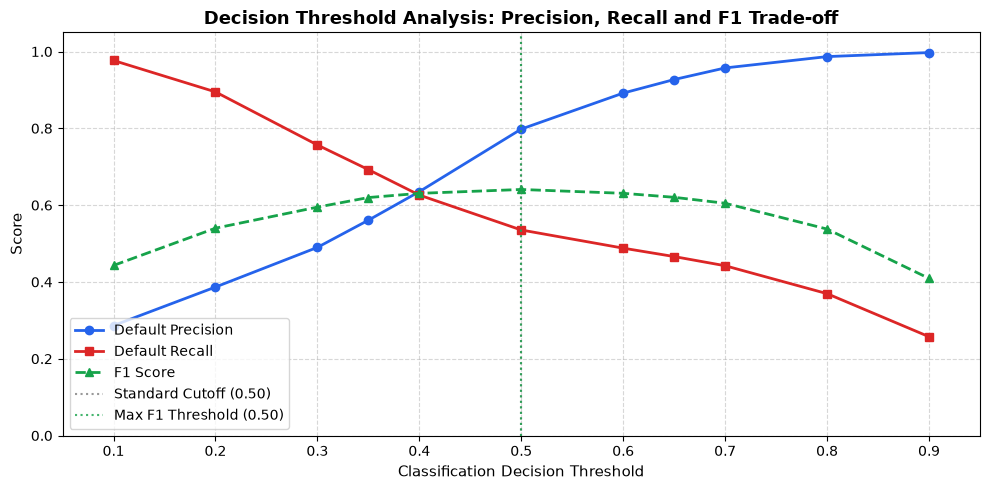

Selected Model: XGBoost
Optimal F1 Decision Threshold: 0.50 (F1 = 0.6408)


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Obtain predicted probabilities of default from best model
y_prob_best = best_model.predict_proba(X_test)[:, 1]

# 2. Evaluate across different decision thresholds
thresholds = [0.10, 0.20, 0.30, 0.35, 0.40, 0.50, 0.60, 0.65, 0.70, 0.80, 0.90]
threshold_metrics = []

for thresh in thresholds:
    y_pred_thresh = (y_prob_best >= thresh).astype(int)
    approved_mask = (y_pred_thresh == 0)
    approval_rate = approved_mask.mean() * 100
    portfolio_default_rate = (
        y_test[approved_mask].mean() * 100 if approved_mask.sum() > 0 else 0.0
    )
    
    precision = precision_score(y_test, y_pred_thresh, zero_division=0)
    recall = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, zero_division=0)
    acc = accuracy_score(y_test, y_pred_thresh)
    
    threshold_metrics.append({
        "Threshold": thresh,
        "Approval Rate (%)": round(approval_rate, 2),
        "Default Precision": round(precision, 4),
        "Default Recall": round(recall, 4),
        "F1 Score": round(f1, 4),
        "Accuracy": round(acc, 4),
        "Portfolio Default Rate (%)": round(portfolio_default_rate, 2)
    })

threshold_df = pd.DataFrame(threshold_metrics)
display(threshold_df)

# 3. Plot Precision, Recall, and F1 trade-off curve
plt.figure(figsize=(10, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Default Precision"], label="Default Precision", color="#2563eb", marker="o", linewidth=2)
plt.plot(threshold_df["Threshold"], threshold_df["Default Recall"], label="Default Recall", color="#dc2626", marker="s", linewidth=2)
plt.plot(threshold_df["Threshold"], threshold_df["F1 Score"], label="F1 Score", color="#16a34a", marker="^", linewidth=2, linestyle="--")

optimal_idx = threshold_df["F1 Score"].idxmax()
optimal_thresh = threshold_df.loc[optimal_idx, "Threshold"]

plt.axvline(x=0.50, color="gray", linestyle=":", alpha=0.8, label="Standard Cutoff (0.50)")
plt.axvline(x=optimal_thresh, color="#16a34a", linestyle=":", alpha=0.8, label=f"Max F1 Threshold ({optimal_thresh:.2f})")

plt.title("Decision Threshold Analysis: Precision, Recall and F1 Trade-off", fontsize=13, fontweight="bold")
plt.xlabel("Classification Decision Threshold", fontsize=11)
plt.ylabel("Score", fontsize=11)
plt.ylim(0, 1.05)
plt.xlim(0.05, 0.95)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="best", frameon=True)
plt.tight_layout()
plt.show()

print(f"Selected Model: {best_model_name}")
print(f"Optimal F1 Decision Threshold: {optimal_thresh:.2f} (F1 = {threshold_df.loc[optimal_idx, 'F1 Score']:.4f})")
